# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [1]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

# TODO: đặt BATCH_SIZE, EPOCHS, LEARNING_RATE, DATA_DIR
# TODO: chọn DEVICE là 'cuda' nếu torch.cuda.is_available(), ngược lại 'cpu'

torch.manual_seed(0)

batch_size = 256
epochs = 5
learning_rate = 0.001
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'PyTorch: {torch.__version__}')
print(f'Thiết bị: {DEVICE}')



PyTorch: 2.13.0+cpu
Thiết bị: cpu


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [4]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DATA_DIR = "./data"
BATCH_SIZE = batch_size  # Hoặc BATCH_SIZE = 256

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

full_train = datasets.EMNIST(
    DATA_DIR, split="letters", train=True, transform=transform, download=True
)
test_set = datasets.EMNIST(
    DATA_DIR, split="letters", train=False, transform=transform, download=True
)

# 1. Dùng random_split tách full_train thành train_set (100.000) và val_set (24.800)
train_set, val_set = random_split(full_train, [100000, 24800])

# 2. Tạo train_loader, val_loader, test_loader
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(len(train_set), len(val_set), len(test_set))

100000 24800 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


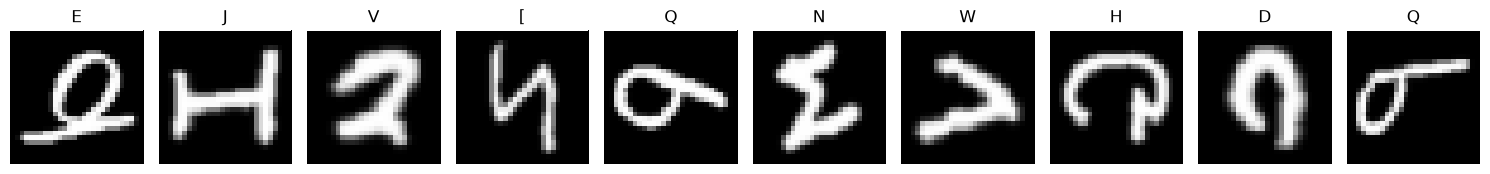

In [5]:
batch_images, batch_labels = next(iter(train_loader))
print("Batch ảnh :", batch_images.shape)
print("Batch nhãn:", batch_labels.shape)

# Vẽ 10 ảnh đầu tiên
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    img = batch_images[i].squeeze()  # Chuyển tensor (1, 28, 28) thành (28, 28)
    label = batch_labels[i].item()

    # Nếu nhãn đã được tiền xử lý về 0-25, dùng trực tiếp công thức bên dưới:
    char_label = chr(label + ord("A"))

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(char_label)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [6]:
LEARNING_RATE = learning_rate  # Hoặc LEARNING_RATE = 0.001
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: định nghĩa các layer
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 26)
        )



    def forward(self, images):
        # TODO: cho images đi qua các layer
        return self.layers(images)

model = EMNISTMLP().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

print(model)

EMNISTMLP(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: lặp qua các batch, cập nhật trọng số, cộng dồn loss và số dự đoán đúng
    # Gợi ý: số dự đoán đúng = (logits.argmax(dim=1) == labels).sum().item()
    for images, labels in loader:
        labels = labels - 1  # Chuyển nhãn từ 1-26 về 0-25
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    # TODO: giống train_one_epoch nhưng bỏ qua backward/step và dùng torch.no_grad()
    with torch.no_grad():
        for images, labels in loader:
            labels = labels - 1  # Chuyển nhãn từ 1-26 về 0-25
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [8]:
EPOCHS = epochs  # Hoặc EPOCHS = 5

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(1, EPOCHS + 1):
    # Huấn luyện và đánh giá
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    # Lưu kết quả vào list
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # In kết quả định dạng
    print(
        f"Epoch {epoch:02d}/{EPOCHS:02d}: "
        f"train loss={train_loss:.4f}, val loss={val_loss:.4f}, "
        f"train acc={train_acc:.4f}, val acc={val_acc:.4f}"
    )

Epoch 01/05: train loss=1.2334, val loss=0.8672, train acc=0.6631, val acc=0.7540
Epoch 02/05: train loss=0.7317, val loss=0.6606, train acc=0.7910, val acc=0.8079
Epoch 03/05: train loss=0.5754, val loss=0.5511, train acc=0.8337, val acc=0.8379
Epoch 04/05: train loss=0.4919, val loss=0.4894, train acc=0.8554, val acc=0.8547
Epoch 05/05: train loss=0.4394, val loss=0.4570, train acc=0.8688, val acc=0.8621


## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

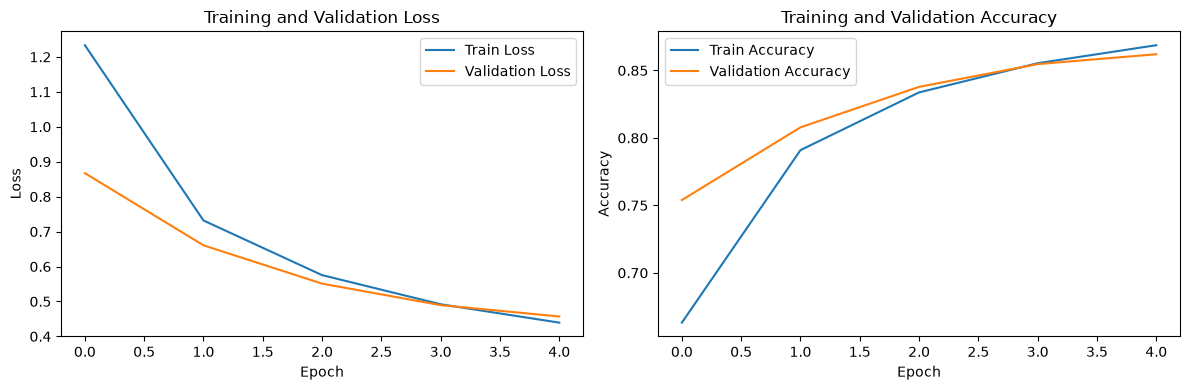

Test loss=0.4648, test accuracy=86.21%
Test loss=0.4648, test accuracy=86.21%


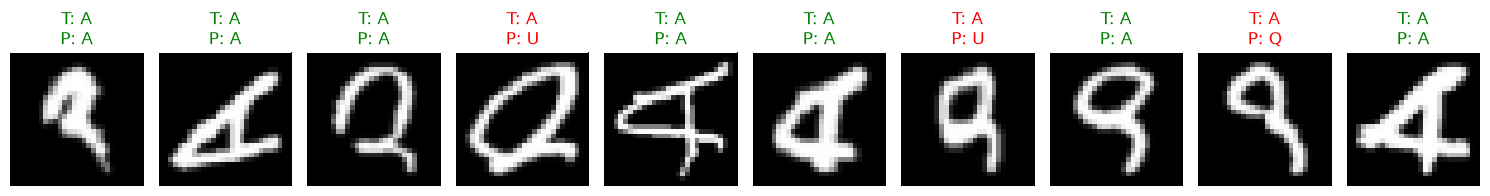

In [9]:
# TODO: vẽ đồ thị Loss và Accuracy theo epoch (train vs val)
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Vẽ đồ thị Loss
axs[0].plot(train_losses, label='Train Loss')
axs[0].plot(val_losses, label='Validation Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training and Validation Loss')
axs[0].legend()

# Vẽ đồ thị Accuracy
axs[1].plot(train_accuracies, label='Train Accuracy')
axs[1].plot(val_accuracies, label='Validation Accuracy')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_title('Training and Validation Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()

test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}')



# 2. Đánh giá trên test_loader
test_loss, test_accuracy = evaluate(model, test_loader, criterion)
print(f"Test loss={test_loss:.4f}, test accuracy={test_accuracy:.2%}")

# TODO: lấy 1 batch từ test_loader và vẽ 10 ảnh kèm nhãn thật + nhãn dự đoán

# 3. Lấy 1 batch từ test_loader và trực quan hóa 10 ảnh kèm dự đoán
model.eval()
test_images, test_labels = next(iter(test_loader))
test_labels = test_labels - 1  # Đưa về khoảng 0-25

with torch.no_grad():
    outputs = model(test_images.to(DEVICE))
    predictions = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2.5))

for i in range(10):
    img = test_images[i].squeeze()
    true_char = chr(test_labels[i].item() + ord("A"))
    pred_char = chr(predictions[i].item() + ord("A"))

    is_correct = test_labels[i].item() == predictions[i].item()
    color = "green" if is_correct else "red"

    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"T: {true_char}\nP: {pred_char}", color=color)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

In [10]:
# TODO: lưu state_dict của model vào file 'emnist_mlp.pt'
torch.save(model.state_dict(), 'emnist_mlp.pt')
